In [64]:
using Random, GMRF

include("src/dataGen.jl");
include("src/cavi.jl");
include("src/mcmc.jl");
include("src/plotting.jl");

Taille de la grille (à ne pas modifier)

In [65]:
M₁ = 5;
M₂ = 5;
M = M₁ * M₂;

- Génération de la grille cible
- Création des données artificielles

In [88]:
Random.seed!(300);
Fmu = iGMRF(M₁, M₂, 1, 10);
Fphi = iGMRF(M₁, M₂, 1, 100);
gridTarget = generateTargetGrid(Fmu, Fphi);
gridTarget[:, :, 1] = gridTarget[:, :, 1] .+ 10.0;
gridTarget[:, :, 2] = gridTarget[:, :, 2] .+ 1.0;
gridTarget[:, :, 3] = gridTarget[:, :, 3] .+ .1;
nobs = 100;
data = generateData(gridTarget, nobs);

# CAVI

In [91]:
nEpoch = 10;
epochSize = 20;

initialValues = Dict(
    :μ => zeros(M),
    :ϕ => zeros(M),
    :ξ => 0.0,
    :κᵤ => ((M - 1) / 2 + 1) / 10,
    :κᵥ => ((M - 1) / 2 + 1) / 100,
);

spatialScheme = Dict(
    :M => M,
    :Fmu => Fmu,
    :Fphi => Fphi,
    :data => data,
);

In [92]:
include("src/cavi.jl");

res = runCAVI(nEpoch, epochSize, initialValues, spatialScheme);

In [95]:
res.traces[:kappaUparams]

2×200 Matrix{Float64}:
 13.0  13.0      13.0      13.0      …  13.0        13.0        13.0
  1.3   1.56359   2.43306   4.85312      0.0102026   0.0102027   0.0102027

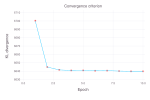

In [93]:
plotConvergenceCriterion(res.MCKL)

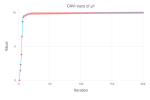

In [96]:
plotTraceCAVI(res.traces[:muMean][1, :], "μ1")

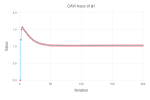

In [97]:
plotTraceCAVI(res.traces[:phiMean][1, :], "ϕ1")

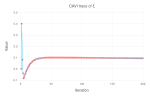

In [98]:
plotTraceCAVI(res.traces[:xiMean], "ξ")

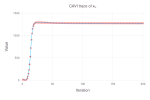

In [99]:
trace = res.traces[:kappaUparams][1, :] ./ res.traces[:kappaUparams][2, :];

plotTraceCAVI(trace, "κᵤ")

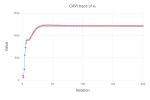

In [100]:
trace = res.traces[:kappaVparams][1, :] ./ res.traces[:kappaVparams][2, :];

plotTraceCAVI(trace, "κᵥ")

# MCMC

In [75]:
datastructure = Dict(
    :Y => data,
    :Fmu => Fmu,
    :Fphi => Fphi,
);

niter = 10000;

initialvalues = Dict(
    :μ => zeros(M),
    :ϕ => zeros(M),
    :ξ => .2,
    :κᵤ => 1.0,
    :κᵥ => 1.0,
);

stepsize = Dict(
    :μ => .65,
    :ϕ => .18,
    :ξ => .07,
);

In [76]:
include("src/mcmc.jl")

chain = mcmc(datastructure, niter, initialvalues, stepsize);

Progress: 100%|█████████████████████████████████████████| Time: 0:00:04


In [ ]:
changerate(chain)

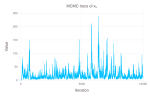

In [77]:
plotTraceMCMC(chain, "κᵤ")

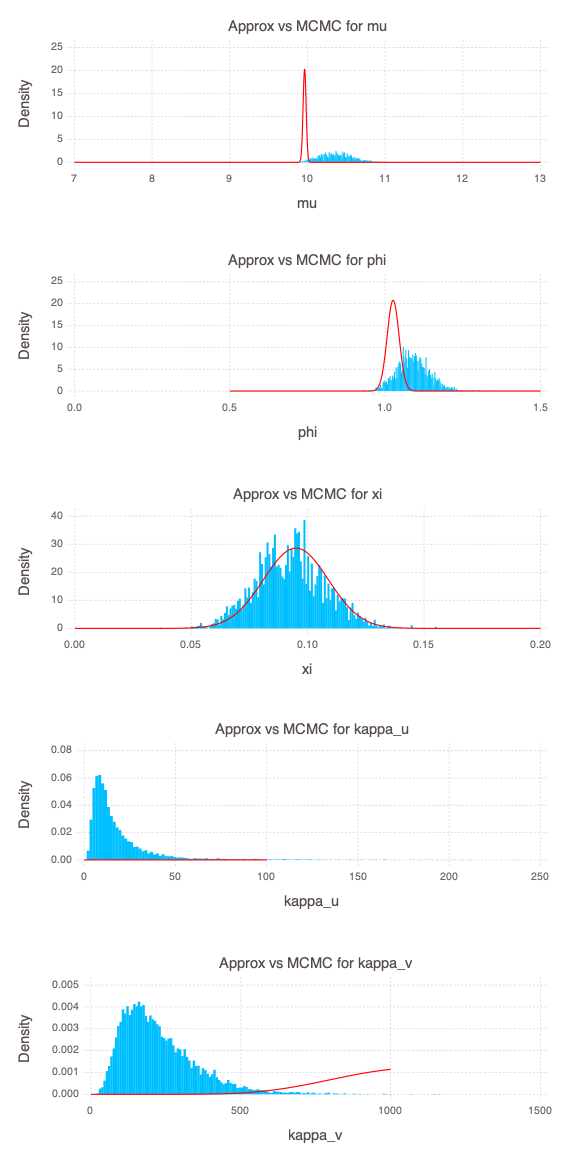

In [79]:
include("src/plotting.jl");

plotCAVIvsMCMC(1, caviRes=res, mcmcChain=chain, warmingSize=1000)